<a href="https://colab.research.google.com/github/Mrudula7-P/Stock-Market-Sentiment-Price-Movement-Predictor/blob/main/Stock_Market_Sentiment_Price_Movement_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [6]:
file_path = "data (2).csv"
df = pd.read_csv(file_path)

print("Dataset Preview:")
print(df.head())


Dataset Preview:
    mic symbol          isin        date  open_value  high_value  low_value  \
0  XZAG    CBX  HRZB00ICBEX6  2015-12-30     1689.22     1689.71    1673.62   
1  XZAG    CBX  HRZB00ICBEX6  2015-12-29     1675.79     1691.02    1673.37   
2  XZAG    CBX  HRZB00ICBEX6  2015-12-28     1655.92     1677.17    1652.76   
3  XZAG    CBX  HRZB00ICBEX6  2015-12-23     1647.66     1655.77    1641.41   
4  XZAG    CBX  HRZB00ICBEX6  2015-12-22     1655.71     1655.71    1642.60   

   last_value  change_prev_close_percentage    turnover  
0     1689.63                         -0.02  2017520.82  
1     1689.94                          0.84  1094356.06  
2     1675.88                          1.21  1125687.29  
3     1655.77                          0.49   592284.75  
4     1647.67                         -0.55  2714509.05  


In [7]:
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

# Fill missing values
df.fillna(method='ffill', inplace=True)

/tmp/ipython-input-1554552183.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [8]:
if 'Headline' in df.columns:
    sid = SentimentIntensityAnalyzer()
    df['Sentiment'] = df['Headline'].apply(
        lambda x: sid.polarity_scores(str(x))['compound']
    )
else:
    print("No Headline column found. Creating neutral sentiment.")
    df['Sentiment'] = 0

No Headline column found. Creating neutral sentiment.


In [9]:
if 'Headline' in df.columns:
    sid = SentimentIntensityAnalyzer()
    df['Sentiment'] = df['Headline'].apply(
        lambda x: sid.polarity_scores(str(x))['compound']
    )
else:
    print("No Headline column found. Creating neutral sentiment.")
    df['Sentiment'] = 0

No Headline column found. Creating neutral sentiment.


In [12]:
df.columns

Index(['mic', 'symbol', 'isin', 'date', 'open_value', 'high_value',
       'low_value', 'last_value', 'change_prev_close_percentage', 'turnover',
       'Sentiment'],
      dtype='object')

In [13]:
df.rename(columns={
    'open_value': 'Open',
    'high_value': 'High',
    'low_value': 'Low',
    'last_value': 'Close',
    'turnover': 'Volume'
}, inplace=True)

In [15]:
df['SMA_5'] = df['Close'].rolling(window=5).mean()
df['SMA_10'] = df['Close'].rolling(window=10).mean()

In [16]:
df['Price_Change'] = df['Close'].pct_change()

In [17]:
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

df.dropna(inplace=True)

In [18]:
features = [
    'Open', 'High', 'Low', 'Close',
    'Volume', 'Sentiment',
    'SMA_5', 'SMA_10', 'Price_Change'
]

X = df[features]
y = df['Target']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [21]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [23]:
y_pred = model.predict(X_test)


Accuracy: 0.610738255033557

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.57      0.60       154
           1       0.59      0.65      0.62       144

    accuracy                           0.61       298
   macro avg       0.61      0.61      0.61       298
weighted avg       0.61      0.61      0.61       298



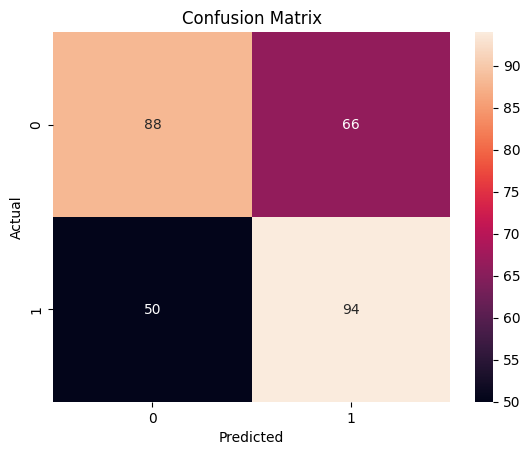

In [24]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Feature Importance:

        Feature  Importance
0          Open    0.250152
3         Close    0.181936
6         SMA_5    0.107549
2           Low    0.103934
1          High    0.099957
4        Volume    0.096495
7        SMA_10    0.084964
8  Price_Change    0.075013
5     Sentiment    0.000000


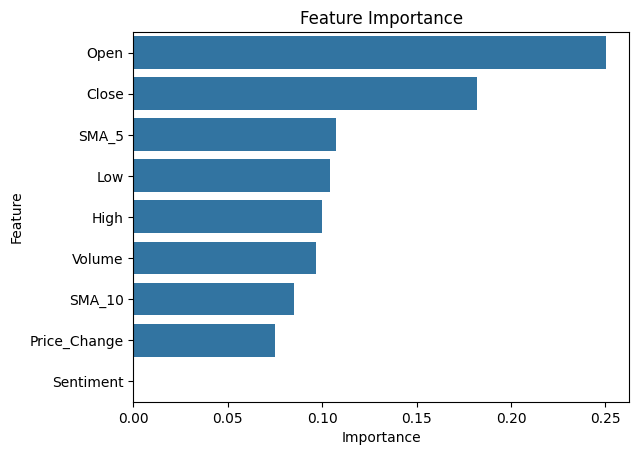

In [25]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n")
print(importance)

plt.figure()
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()